<a href="https://colab.research.google.com/github/Amyriki/copd-metabolic-data-analysis/blob/main/notebooks/01_explore_nhanes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

print("Hello COPD 🫁")

Hello COPD 🫁


In [2]:
df = pd.read_sas("/content/SPX_G.XPT")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/SPX_G.XPT'

In [3]:
import os

os.listdir("/content")

['.config', 'sample_data']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
import os
os.listdir("/content")

['.config', 'sample_data']

In [5]:
import pandas as pd

df = pd.read_sas("/SPX_G.xpt")

df.head()

,SEQN,ENQ010,ENQ020,SPQ010,SPQ020,SPQ030,SPQ040,SPQ050,SPQ060,SPQ070A,...,SPXBFEV1,SPXBFEV3,SPXBFEV6,SPXBPEF,SPXBF257,SPXBFET,SPXBQFVC,SPXBQFV1,SPDBACC,SPXBQEFF
0,62161.0,2.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,b'',b'',NaN,b''
1,62163.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,b'',b'',NaN,b''
2,62164.0,2.0,2.0,NaN,1.0,2.0,2.0,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,b'',b'',NaN,b''
3,62165.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,b'',b'',NaN,b''
4,62166.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,b'',b'',NaN,b''


In [6]:
df.shape

(7495, 51)

In [7]:
df.columns.tolist()

['SEQN',
 'ENQ010',
 'ENQ020',
 'SPQ010',
 'SPQ020',
 'SPQ030',
 'SPQ040',
 'SPQ050',
 'SPQ060',
 'SPQ070A',
 'SPQ070B',
 'SPQ070C',
 'SPQ070D',
 'SPQ070E',
 'SPQ080',
 'SPQ090',
 'SPQ100',
 'ENQ100',
 'SPXNSTAT',
 'SPXNCMT',
 'SPXNFVC',
 'SPXNEV',
 'SPXNFEV5',
 'SPXNFEV7',
 'SPXNFEV1',
 'SPXNFEV3',
 'SPXNFEV6',
 'SPXNPEF',
 'SPXNF257',
 'SPXNFET',
 'SPXNQFVC',
 'SPXNQFV1',
 'SPDNACC',
 'SPXNQEFF',
 'SPDBRONC',
 'SPXBSTAT',
 'SPXBCMT',
 'SPXBFVC',
 'SPXBEV',
 'SPXBFEV5',
 'SPXBFEV7',
 'SPXBFEV1',
 'SPXBFEV3',
 'SPXBFEV6',
 'SPXBPEF',
 'SPXBF257',
 'SPXBFET',
 'SPXBQFVC',
 'SPXBQFV1',
 'SPDBACC',
 'SPXBQEFF']

In [8]:
lung = df[["SEQN", "SPXNFEV1", "SPXNFVC"]]

lung.head()

,SEQN,SPXNFEV1,SPXNFVC
0,62161.0,4265.0,4536.0
1,62163.0,3563.0,3667.0
2,62164.0,3397.0,4566.0
3,62165.0,2207.0,2531.0
4,62166.0,1715.0,1822.0


In [9]:
lung.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7495 entries, 0 to 7494
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      7495 non-null   float64
 1   SPXNFEV1  6652 non-null   float64
 2   SPXNFVC   6652 non-null   float64
dtypes: float64(3)
memory usage: 175.8 KB


In [10]:
lung["FEV1_FVC"] = lung["SPXNFEV1"] / lung["SPXNFVC"]

lung.head()

/tmp/ipykernel_1816/447322410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lung["FEV1_FVC"] = lung["SPXNFEV1"] / lung["SPXNFVC"]


,SEQN,SPXNFEV1,SPXNFVC,FEV1_FVC
0,62161.0,4265.0,4536.0,0.940256
1,62163.0,3563.0,3667.0,0.971639
2,62164.0,3397.0,4566.0,0.743977
3,62165.0,2207.0,2531.0,0.871987
4,62166.0,1715.0,1822.0,0.941273


In [11]:
lung["FEV1_FVC"].describe()

,FEV1_FVC
count,6652.000000
mean,0.815163
std,0.087071
min,0.313041
25%,0.765642
50%,0.822748
75%,0.872915
max,1.000000


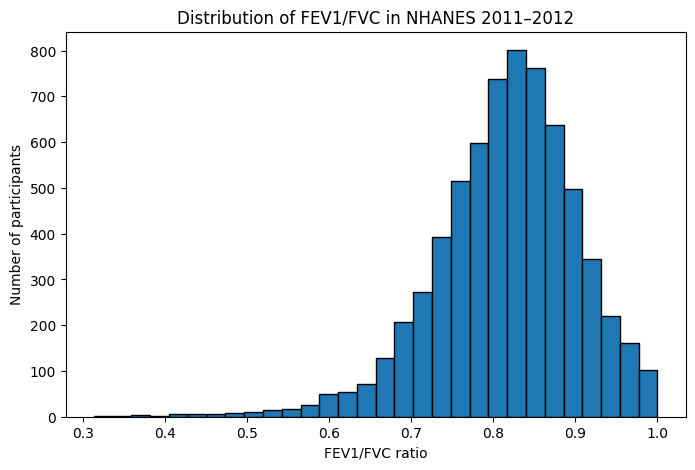

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    lung["FEV1_FVC"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.xlabel("FEV1/FVC ratio")
plt.ylabel("Number of participants")
plt.title("Distribution of FEV1/FVC in NHANES 2011–2012")

plt.show()

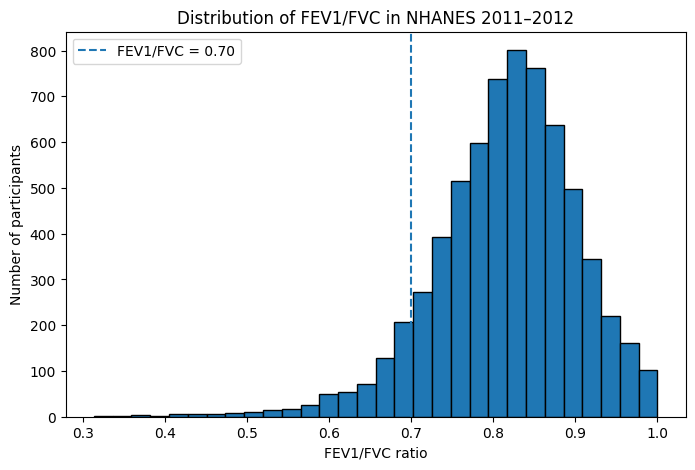

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    lung["FEV1_FVC"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0.70,
    linestyle="--",
    label="FEV1/FVC = 0.70"
)

plt.xlabel("FEV1/FVC ratio")
plt.ylabel("Number of participants")
plt.title("Distribution of FEV1/FVC in NHANES 2011–2012")
plt.legend()

plt.show()

In [14]:
below_070 = (lung["FEV1_FVC"] < 0.70).sum()

below_070

np.int64(586)

In [15]:
valid = lung["FEV1_FVC"].notna().sum()

below_070 / valid * 100

np.float64(8.809380637402285)

## Exploring the distribution of lung function

FEV1/FVC was calculated from baseline spirometry measurements.
I first examined its distribution before investigating potential
clinical or metabolic factors associated with lower lung function.

In [16]:
demo = pd.read_sas("/DEMO_G.xpt")
demo.shape

(9756, 48)

In [17]:
demo_small = demo[["SEQN", "RIDAGEYR", "RIAGENDR"]]

demo_small.head()

,SEQN,RIDAGEYR,RIAGENDR
0,62161.0,22.0,1.0
1,62162.0,3.0,2.0
2,62163.0,14.0,1.0
3,62164.0,44.0,2.0
4,62165.0,14.0,2.0


In [18]:
merged = lung.merge(
    demo_small,
    on="SEQN",
    how="left"
)

merged.head()

,SEQN,SPXNFEV1,SPXNFVC,FEV1_FVC,RIDAGEYR,RIAGENDR
0,62161.0,4265.0,4536.0,0.940256,22.0,1.0
1,62163.0,3563.0,3667.0,0.971639,14.0,1.0
2,62164.0,3397.0,4566.0,0.743977,44.0,2.0
3,62165.0,2207.0,2531.0,0.871987,14.0,2.0
4,62166.0,1715.0,1822.0,0.941273,9.0,1.0


In [19]:
merged.shape

(7495, 6)

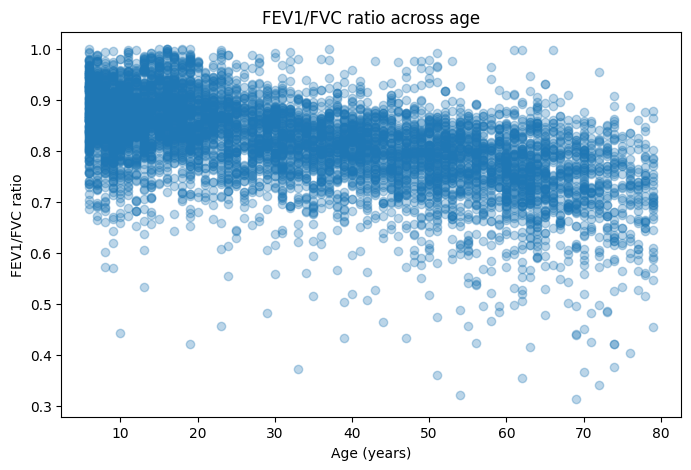

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    merged["RIDAGEYR"],
    merged["FEV1_FVC"],
    alpha=0.3
)

plt.xlabel("Age (years)")
plt.ylabel("FEV1/FVC ratio")
plt.title("FEV1/FVC ratio across age")

plt.show()

In [21]:
merged[["RIDAGEYR", "FEV1_FVC"]].corr()

,RIDAGEYR,FEV1_FVC
RIDAGEYR,1.000000,-0.542905
FEV1_FVC,-0.542905,1.000000


In [22]:
analysis = merged[merged["RIDAGEYR"] >= 40].copy()

analysis.shape

(3115, 6)

In [23]:
merged["RIDAGEYR"] >= 40

,RIDAGEYR
0,False
1,False
2,True
3,False
4,False
...,...
7490,True
7491,False
7492,False
7493,True


In [25]:
analysis = merged[merged["RIDAGEYR"] >= 40].copy()

analysis.shape

(3115, 6)

In [26]:
analysis["FEV1_FVC"].count()

np.int64(2639)

In [27]:
analysis["RIDAGEYR"].describe()

,RIDAGEYR
count,3115.000000
mean,57.251043
std,10.687415
min,40.000000
25%,48.000000
50%,57.000000
75%,65.000000
max,79.000000


In [28]:
analysis[["RIDAGEYR", "FEV1_FVC"]].corr()

,RIDAGEYR,FEV1_FVC
RIDAGEYR,1.000000,-0.311121
FEV1_FVC,-0.311121,1.000000


In [29]:
bmx = pd.read_sas("/BMX_G.xpt")

bmx.shape

(9338, 26)

In [30]:
bmx[["SEQN", "BMXBMI"]].head()

,SEQN,BMXBMI
0,62161.0,23.3
1,62162.0,14.2
2,62163.0,17.3
3,62164.0,23.2
4,62165.0,27.2


In [31]:
bmx["BMXBMI"].describe()

,BMXBMI
count,8602.000000
mean,25.339537
std,7.717103
min,12.400000
25%,19.300000
50%,24.500000
75%,29.800000
max,82.100000


In [32]:
bmi_small = bmx[["SEQN", "BMXBMI"]]

analysis = analysis.merge(
    bmi_small,
    on="SEQN",
    how="left"
)

analysis.shape

(3115, 7)

In [33]:
analysis["BMXBMI"].describe()

,BMXBMI
count,3066.000000
mean,29.521135
std,6.872617
min,13.600000
25%,24.700000
50%,28.300000
75%,32.875000
max,82.100000


In [34]:
analysis["BMXBMI"].isna().sum()

np.int64(49)

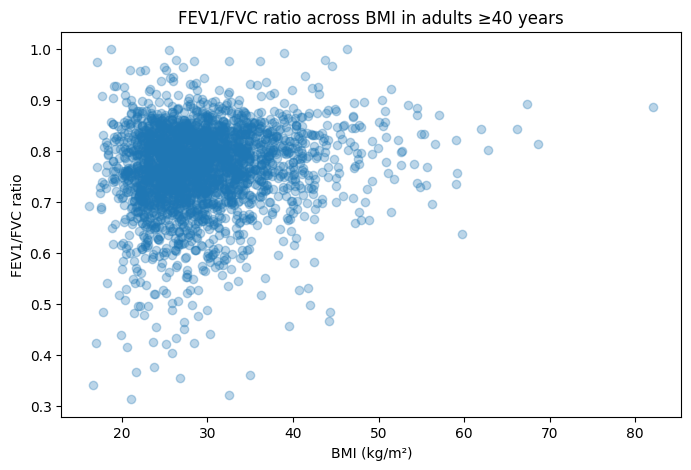

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis["BMXBMI"],
    analysis["FEV1_FVC"],
    alpha=0.3
)

plt.xlabel("BMI (kg/m²)")
plt.ylabel("FEV1/FVC ratio")
plt.title("FEV1/FVC ratio across BMI in adults ≥40 years")

plt.show()

In [36]:
analysis[["BMXBMI", "FEV1_FVC"]].corr()

,BMXBMI,FEV1_FVC
BMXBMI,1.000000,0.136717
FEV1_FVC,0.136717,1.000000


In [37]:
analysis[["RIDAGEYR", "BMXBMI", "FEV1_FVC"]].corr()

,RIDAGEYR,BMXBMI,FEV1_FVC
RIDAGEYR,1.000000,-0.024686,-0.311121
BMXBMI,-0.024686,1.000000,0.136717
FEV1_FVC,-0.311121,0.136717,1.000000


In [38]:
smq = pd.read_sas("/SMQ_G.xpt")

smq.shape

(6790, 30)

In [39]:
smq.columns.tolist()

['SEQN',
 'SMQ020',
 'SMD030',
 'SMQ040',
 'SMQ050Q',
 'SMQ050U',
 'SMD055',
 'SMD057',
 'SMQ077',
 'SMD641',
 'SMD650',
 'SMD093',
 'SMDUPCA',
 'SMD100BR',
 'SMD100FL',
 'SMD100MN',
 'SMD100LN',
 'SMD100TR',
 'SMD100NI',
 'SMD100CO',
 'SMQ621',
 'SMD630',
 'SMQ660',
 'SMQ664M',
 'SMQ664C',
 'SMQ664W',
 'SMQ664B',
 'SMQ664O',
 'SMQ670',
 'SMAQUEX2']

In [40]:
smq[["SEQN", "SMQ020", "SMQ040"]].head(15)

,SEQN,SMQ020,SMQ040
0,62161.0,2.0,NaN
1,62163.0,NaN,NaN
2,62164.0,2.0,NaN
3,62165.0,NaN,NaN
4,62169.0,2.0,NaN
5,62170.0,NaN,NaN
6,62171.0,NaN,NaN
7,62172.0,1.0,1.0
8,62174.0,2.0,NaN
9,62176.0,2.0,NaN


In [41]:
smq["SMQ020"].value_counts(dropna=False)

,count
SMQ020,
2.0,3184
1.0,2369
NaN,1231
9.0,4
7.0,2


In [42]:
smq["SMQ040"].value_counts(dropna=False)

,count
SMQ040,
NaN,4421
3.0,1259
1.0,912
2.0,196
7.0,2


In [45]:
smq["SmokingStatus"] = "Unknown"

smq.loc[smq["SMQ020"] == 2, "SmokingStatus"] = "Never"

smq.loc[
    (smq["SMQ020"] == 1) & (smq["SMQ040"] == 3),
    "SmokingStatus"
] = "Former"

smq.loc[
    (smq["SMQ020"] == 1) & (smq["SMQ040"].isin([1, 2])),
    "SmokingStatus"
] = "Current"

In [46]:
smq["SmokingStatus"].value_counts()

,count
SmokingStatus,
Never,3184
Former,1259
Unknown,1239
Current,1108


In [47]:
smoking_small = smq[["SEQN", "SmokingStatus"]]

analysis = analysis.merge(
    smoking_small,
    on="SEQN",
    how="left"
)

analysis.shape

(3115, 8)

In [48]:
analysis["SmokingStatus"].value_counts(dropna=False)

,count
SmokingStatus,
Never,1651
Former,850
Current,610
Unknown,4


In [49]:
analysis[
    analysis["SmokingStatus"].isin(["Never", "Former", "Current"])
].groupby("SmokingStatus")["FEV1_FVC"].describe()

,count,mean,std,min,25%,50%,75%,max
SmokingStatus,,,,,,,,
Current,519.0,0.727982,0.094937,0.313041,0.678393,0.743549,0.791697,0.999351
Former,706.0,0.746418,0.086218,0.340486,0.701555,0.756720,0.803408,0.974154
Never,1410.0,0.786405,0.070019,0.359688,0.746322,0.793031,0.832593,0.998956


In [50]:
analysis[
    analysis["SmokingStatus"].isin(["Never", "Former", "Current"])
].groupby("SmokingStatus")["RIDAGEYR"].describe()

,count,mean,std,min,25%,50%,75%,max
SmokingStatus,,,,,,,,
Current,610.0,54.786885,9.708248,40.0,47.0,54.0,61.0,79.0
Former,850.0,60.841176,10.563040,40.0,53.0,62.0,69.0,79.0
Never,1651.0,56.325257,10.650547,40.0,47.0,56.0,64.0,79.0


In [51]:
model_data = analysis[
    ["FEV1_FVC", "RIDAGEYR", "BMXBMI", "SmokingStatus"]
].copy()

model_data = model_data[
    model_data["SmokingStatus"].isin(["Never", "Former", "Current"])
]

model_data = model_data.dropna()

model_data.shape

(2609, 4)

In [52]:
model_data.head()

,FEV1_FVC,RIDAGEYR,BMXBMI,SmokingStatus
0,0.743977,44.0,23.2,Never
1,0.807548,43.0,33.3,Current
2,0.709987,51.0,20.1,Current
3,0.837972,55.0,27.6,Never
5,0.783087,57.0,28.0,Former


In [53]:
import statsmodels.formula.api as smf

model = smf.ols(
    "FEV1_FVC ~ RIDAGEYR + BMXBMI + C(SmokingStatus)",
    data=model_data
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               FEV1_FVC   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     153.1
Date:                Wed, 23 Sep 2026   Prob (F-statistic):          9.14e-118
Time:                        15:47:20   Log-Likelihood:                 3045.6
No. Observations:                2609   AIC:                            -6081.
Df Residuals:                    2604   BIC:                            -6052.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [55]:
results = pd.DataFrame({
    "Coefficient": model.params,
    "P_value": model.pvalues,
    "CI_lower": model.conf_int()[0],
    "CI_upper": model.conf_int()[1]
})

results.round(4)

,Coefficient,P_value,CI_lower,CI_upper
Intercept,0.8252,0.0,0.8042,0.8462
C(SmokingStatus)[T.Former],0.0299,0.0,0.0210,0.0387
C(SmokingStatus)[T.Never],0.0596,0.0,0.0519,0.0673
RIDAGEYR,-0.0024,0.0,-0.0027,-0.0022
BMXBMI,0.0013,0.0,0.0008,0.0017


In [57]:
model_data["FEV1_L"] = analysis.loc[model_data.index, "SPXNFEV1"] / 1000
model_data["FVC_L"] = analysis.loc[model_data.index, "SPXNFVC"] / 1000

In [58]:
model_data = analysis[
    ["SPXNFEV1", "SPXNFVC", "FEV1_FVC",
     "RIDAGEYR", "BMXBMI", "SmokingStatus"]
].copy()

model_data = model_data[
    model_data["SmokingStatus"].isin(["Never", "Former", "Current"])
].dropna()

model_data["FEV1_L"] = model_data["SPXNFEV1"] / 1000
model_data["FVC_L"] = model_data["SPXNFVC"] / 1000

model_data.shape

(2609, 8)

In [59]:
model_fev1 = smf.ols(
    "FEV1_L ~ RIDAGEYR + BMXBMI + C(SmokingStatus)",
    data=model_data
).fit()

model_fvc = smf.ols(
    "FVC_L ~ RIDAGEYR + BMXBMI + C(SmokingStatus)",
    data=model_data
).fit()

In [60]:
comparison = pd.DataFrame({
    "FEV1": model_fev1.params,
    "FVC": model_fvc.params,
    "FEV1/FVC": model.params
})

comparison.round(4)

,FEV1,FVC,FEV1/FVC
Intercept,4.9997,6.2801,0.8252
C(SmokingStatus)[T.Former],0.1452,0.0382,0.0299
C(SmokingStatus)[T.Never],-0.0622,-0.3582,0.0596
RIDAGEYR,-0.0343,-0.0339,-0.0024
BMXBMI,-0.0135,-0.0230,0.0013


In [62]:
demo["RIAGENDR"].value_counts(dropna=False)

,count
RIAGENDR,
2.0,4900
1.0,4856


In [63]:
"RIAGENDR" in analysis.columns

True

In [64]:
model_data = analysis[
    ["SPXNFEV1", "SPXNFVC", "FEV1_FVC",
     "RIDAGEYR", "RIAGENDR", "BMXBMI", "SmokingStatus"]
].copy()

model_data = model_data[
    model_data["SmokingStatus"].isin(["Never", "Former", "Current"])
].dropna()

model_data["FEV1_L"] = model_data["SPXNFEV1"] / 1000
model_data["FVC_L"] = model_data["SPXNFVC"] / 1000

model_data.shape

(2609, 9)

In [65]:
pd.crosstab(
    model_data["SmokingStatus"],
    model_data["RIAGENDR"],
    normalize="index"
).round(3)

RIAGENDR,1.0,2.0
SmokingStatus,,
Current,0.626,0.374
Former,0.617,0.383
Never,0.380,0.620


In [66]:
model_fev1_sex = smf.ols(
    "FEV1_L ~ RIDAGEYR + BMXBMI + C(SmokingStatus) + C(RIAGENDR)",
    data=model_data
).fit()

model_fvc_sex = smf.ols(
    "FVC_L ~ RIDAGEYR + BMXBMI + C(SmokingStatus) + C(RIAGENDR)",
    data=model_data
).fit()

model_ratio_sex = smf.ols(
    "FEV1_FVC ~ RIDAGEYR + BMXBMI + C(SmokingStatus) + C(RIAGENDR)",
    data=model_data
).fit()

In [67]:
before_after = pd.DataFrame({
    "FEV1_before": model_fev1.params,
    "FEV1_after": model_fev1_sex.params,
    "FVC_before": model_fvc.params,
    "FVC_after": model_fvc_sex.params
})

before_after.round(4)

,FEV1_before,FEV1_after,FVC_before,FVC_after
BMXBMI,-0.0135,-0.0074,-0.0230,-0.0146
C(RIAGENDR)[T.2.0],NaN,-0.8803,NaN,-1.2273
C(SmokingStatus)[T.Former],0.1452,0.1378,0.0382,0.0280
C(SmokingStatus)[T.Never],-0.0622,0.1430,-0.3582,-0.0721
Intercept,4.9997,5.1400,6.2801,6.4756
RIDAGEYR,-0.0343,-0.0339,-0.0339,-0.0333
